# Client Level KPI Analysis

## Purpose

This notebook evaluates the primary Vanguard A/B test KPIs at the client level.

The Vanguard experiment was assigned at the client level. Therefore, `client_id` is used as the primary independent analytical unit.

Each randomized client contributes one observation to the primary outcome analysis regardless of the number of journeys or attempts generated.

The full experimental population contains 50,500 clients:

Control: 23,532 clients

Test: 26,968 clients

Clients remain in their originally assigned experimental group even when no process start is observed.

Journey level metrics from Notebook 03 are retained as secondary process diagnostics and are not treated as independent client observations for the primary A/B test.

In [3]:
import pandas as pd
import numpy as np

In [6]:
import os

print(os.getcwd())

/Users/jannoelvero/Documents/Ironhack/week_6/Week_6_Project


In [7]:
print(os.listdir())

[' 02_customer_profile_group_comparison.ipynb', '.DS_Store', '03_B_journey_level_analysis.ipynb', 'tableau', 'requirements.txt', 'uv.lock', 'images', '03_customer_journey_analysis.ipynb', 'pyproject.toml', 'README.md', '.gitignore', '.venv', '.python-version', '.ipynb_checkpoints', '.git', 'data', 'notebooks', 'src', 'sql']


In [9]:


experiment_clients_df = pd.read_csv(
    "data/cleaned/experiment_clients.csv"
)

web_clean_df = pd.read_csv(
    "data/cleaned/web_clean.csv"
)

print("Experiment clients:", experiment_clients_df.shape)
print("Web events:", web_clean_df.shape)

Experiment clients: (70609, 2)
Web events: (744641, 8)


In [10]:
# Check column names

print("Experiment client columns:")
print(experiment_clients_df.columns.tolist())

print()

print("Web event columns:")
print(web_clean_df.columns.tolist())

Experiment client columns:
['client_id', 'Variation']

Web event columns:
['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time', 'step_number', 'previous_step', 'backward_navigation']


In [11]:
# Create valid experimental client population

valid_experiment_clients = experiment_clients_df[
    experiment_clients_df["Variation"].isin(["Control", "Test"])
].copy()

valid_experiment_clients = (
    valid_experiment_clients
    .drop_duplicates(subset="client_id")
    .reset_index(drop=True)
)

print(
    "Valid experimental clients:",
    len(valid_experiment_clients)
)

print(
    "Unique clients:",
    valid_experiment_clients["client_id"].nunique()
)

print()

print(
    valid_experiment_clients["Variation"].value_counts()
)

Valid experimental clients: 50500
Unique clients: 50500

Variation
Test       26968
Control    23532
Name: count, dtype: int64


In [12]:
# Check whether any client is assigned to multiple variations

client_variation_check = (
    experiment_clients_df[
        experiment_clients_df["Variation"].isin(["Control", "Test"])
    ]
    .groupby("client_id")["Variation"]
    .nunique()
)

conflicting_clients = client_variation_check[
    client_variation_check > 1
]

print(
    "Clients assigned to multiple variations:",
    len(conflicting_clients)
)

Clients assigned to multiple variations: 0


In [13]:
# Create client level completion status

client_completion_status = (
    web_clean_df
    .groupby("client_id")["process_step"]
    .apply(lambda x: (x == "confirm").any())
    .reset_index(name="completed")
)

client_completion_status.head()

,client_id,completed
0,169,True
1,336,False
2,546,True
3,555,True
4,647,True


In [14]:
client_kpi_df = valid_experiment_clients.merge(
    client_completion_status,
    on="client_id",
    how="left"
)

client_kpi_df["completed"] = (
    client_kpi_df["completed"]
    .fillna(False)
    .astype(bool)
)

print("Client KPI rows:", len(client_kpi_df))
print(
    "Unique clients:",
    client_kpi_df["client_id"].nunique()
)

print(
    "Missing completion status:",
    client_kpi_df["completed"].isna().sum()
)

client_kpi_df.head()

Client KPI rows: 50500
Unique clients: 50500
Missing completion status: 0


,client_id,Variation,completed
0,9988021,Test,False
1,8320017,Test,True
2,4033851,Control,True
3,1982004,Test,True
4,9294070,Control,False


In [15]:
client_completion_summary = (
    client_kpi_df
    .groupby("Variation")
    .agg(
        assigned_clients=("client_id", "count"),
        completed_clients=("completed", "sum")
    )
)

client_completion_summary["completion_rate"] = (
    client_completion_summary["completed_clients"]
    / client_completion_summary["assigned_clients"]
    * 100
)

client_completion_summary.round(2)

,assigned_clients,completed_clients,completion_rate
Variation,,,
Control,23532,15434,65.59
Test,26968,18687,69.29


Previous among starters:
Control completed = 14,919
Test completed = 17,906

Current all clients:
Control completed = 15,434
Test completed = 18,687

In [16]:
# Identify clients with an observed start

client_start_status = (
    web_clean_df
    .groupby("client_id")["process_step"]
    .apply(lambda x: (x == "start").any())
    .reset_index(name="has_start")
)

# Add start status to the client KPI dataset

client_kpi_df = client_kpi_df.merge(
    client_start_status,
    on="client_id",
    how="left"
)

client_kpi_df["has_start"] = (
    client_kpi_df["has_start"]
    .fillna(False)
    .astype(bool)
)

# Check completion and start combinations

start_completion_check = (
    client_kpi_df
    .groupby(
        ["Variation", "has_start", "completed"]
    )
    .size()
    .reset_index(name="clients")
)

start_completion_check

,Variation,has_start,completed,clients
0,Control,False,False,19
1,Control,False,True,116
2,Control,True,False,8079
3,Control,True,True,15318
4,Test,False,False,14
5,Test,False,True,275
6,Test,True,False,8267
7,Test,True,True,18412


In [17]:
# Clients with confirm but no observed start

confirm_without_start = client_kpi_df[
    (client_kpi_df["completed"] == True)
    & (client_kpi_df["has_start"] == False)
]

print(
    "Completed clients without observed start:",
    len(confirm_without_start)
)

print()

print(
    confirm_without_start["Variation"]
    .value_counts()
)

Completed clients without observed start: 391

Variation
Test       275
Control    116
Name: count, dtype: int64


### Completion KPI Definition

The primary completion KPI is calculated at the client level because clients were the unit of experimental assignment.

Each of the 50,500 randomized clients contributes one observation.

A client is classified as completed if at least one `confirm` event is observed in the web activity data. Clients without a `confirm` event are classified as not completed.

The analysis identified 391 clients with a recorded `confirm` event but no recorded `start` event. These clients are retained as completed because the primary outcome measures whether the client reached confirmation rather than whether a complete event sequence was captured.

The missing start events are documented as a data quality and journey tracking limitation and can be investigated separately in the secondary journey level analysis.

In [18]:
# Final validation of client level completion KPI

print(
    "Total clients:",
    len(client_kpi_df)
)

print(
    "Unique clients:",
    client_kpi_df["client_id"].nunique()
)

print(
    "Completed clients:",
    client_kpi_df["completed"].sum()
)

print(
    "Not completed clients:",
    (~client_kpi_df["completed"]).sum()
)

print()

print(
    client_kpi_df.groupby(
        ["Variation", "completed"]
    ).size()
)

Total clients: 50500
Unique clients: 50500
Completed clients: 34121
Not completed clients: 16379

Variation  completed
Control    False         8098
           True         15434
Test       False         8281
           True         18687
dtype: int64


### Completion Rate Result

The client level completion KPI includes all 50,500 randomized clients and preserves each client's original experimental assignment.

The Control group contained 23,532 clients, of whom 15,434 reached confirmation at least once, resulting in a completion rate of 65.59%.

The Test group contained 26,968 clients, of whom 18,687 reached confirmation at least once, resulting in a completion rate of 69.29%.

The Test group therefore shows an observed improvement of 3.70 percentage points over the Control group.

Each client contributes only one observation to this KPI regardless of the number of journeys or attempts made. This aligns the analytical unit with the client level experimental assignment.

Statistical significance will be evaluated separately during the A/B hypothesis testing stage.

### Client Level Noncompletion Rate


In [19]:
# Create client level noncompletion status

client_kpi_df["not_completed"] = (
    ~client_kpi_df["completed"]
)

client_kpi_df[
    ["client_id", "Variation", "completed", "not_completed"]
].head()

,client_id,Variation,completed,not_completed
0,9988021,Test,False,True
1,8320017,Test,True,False
2,4033851,Control,True,False
3,1982004,Test,True,False
4,9294070,Control,False,True


In [20]:
# Validate noncompletion status

print(
    client_kpi_df["not_completed"]
    .value_counts()
)

print()

print(
    client_kpi_df
    .groupby(["Variation", "not_completed"])
    .size()
)

not_completed
False    34121
True     16379
Name: count, dtype: int64

Variation  not_completed
Control    False            15434
           True              8098
Test       False            18687
           True              8281
dtype: int64


In [21]:
# Calculate client level noncompletion rate

noncompletion_summary = (
    client_kpi_df
    .groupby("Variation")
    .agg(
        assigned_clients=("client_id", "count"),
        not_completed_clients=("not_completed", "sum")
    )
)

noncompletion_summary["noncompletion_rate"] = (
    noncompletion_summary["not_completed_clients"]
    / noncompletion_summary["assigned_clients"]
    * 100
)

noncompletion_summary.round(2)

,assigned_clients,not_completed_clients,noncompletion_rate
Variation,,,
Control,23532,8098,34.41
Test,26968,8281,30.71


### Noncompletion Rate Result

The client level noncompletion rate measures the proportion of all randomized clients who did not reach confirmation at least once.

The Control group recorded a noncompletion rate of 34.41%, compared with 30.71% for the Test group.

The Test group therefore shows an observed reduction in noncompletion of 3.70 percentage points.

Completion and noncompletion are complementary outcomes calculated from the same client population. Therefore, noncompletion will be reported as a supporting business metric rather than tested as a separate independent hypothesis.

### Completion Time

In [22]:
# Prepare experimental web events

experiment_web_df = web_clean_df[
    web_clean_df["client_id"].isin(
        valid_experiment_clients["client_id"]
    )
].copy()

experiment_web_df = experiment_web_df.merge(
    valid_experiment_clients,
    on="client_id",
    how="left"
)

experiment_web_df["date_time"] = pd.to_datetime(
    experiment_web_df["date_time"]
)

experiment_web_df = experiment_web_df.sort_values(
    ["client_id", "visit_id", "date_time"]
)

print(
    "Experimental web events:",
    len(experiment_web_df)
)

print(
    "Unique experimental clients with web events:",
    experiment_web_df["client_id"].nunique()
)

print(
    "Missing Variation:",
    experiment_web_df["Variation"].isna().sum()
)

Experimental web events: 317235
Unique experimental clients with web events: 50500
Missing Variation: 0


In [23]:
# Identify start and confirm time for each journey

journey_times = (
    experiment_web_df
    .groupby(
        ["client_id", "visit_id", "Variation"]
    )
    .agg(
        start_time=(
            "date_time",
            lambda x: x[
                experiment_web_df.loc[x.index, "process_step"] == "start"
            ].min()
        ),
        confirm_time=(
            "date_time",
            lambda x: x[
                experiment_web_df.loc[x.index, "process_step"] == "confirm"
            ].min()
        )
    )
    .reset_index()
)

journey_times.head()

,client_id,visit_id,Variation,start_time,confirm_time
0,555,637149525_38041617439_716659,Test,2017-04-15 12:57:56,2017-04-15 13:00:34
1,647,40369564_40101682850_311847,Test,2017-04-12 15:41:28,2017-04-12 15:47:45
2,934,7076463_57954418406_971348,Test,2017-04-18 02:36:30,NaT
3,1028,557292053_87239438319_391157,Control,2017-04-08 18:51:28,NaT
4,1104,543158812_46395476577_767725,Control,2017-06-12 07:49:18,NaT


In [24]:
# Keep journeys with start followed by confirm

completed_journeys = journey_times[
    journey_times["start_time"].notna()
    & journey_times["confirm_time"].notna()
    & (
        journey_times["confirm_time"]
        >= journey_times["start_time"]
    )
].copy()

completed_journeys["completion_minutes"] = (
    completed_journeys["confirm_time"]
    - completed_journeys["start_time"]
).dt.total_seconds() / 60

print(
    "Valid completed journeys:",
    len(completed_journeys)
)

print(
    "Unique clients with valid completed journeys:",
    completed_journeys["client_id"].nunique()
)

completed_journeys[
    "completion_minutes"
].describe()

Valid completed journeys: 32859
Unique clients with valid completed journeys: 32791


count    32859.000000
mean         6.368577
std          7.394112
min          0.533333
25%          2.633333
50%          4.233333
75%          7.266667
max        300.250000
Name: completion_minutes, dtype: float64

In [25]:
# Sort successful journeys by confirmation time

completed_journeys = completed_journeys.sort_values(
    ["client_id", "confirm_time"]
)

# Keep the first successful completion for each client

client_completion_time = (
    completed_journeys
    .drop_duplicates(
        subset="client_id",
        keep="first"
    )
    .copy()
)

print(
    "Client completion time rows:",
    len(client_completion_time)
)

print(
    "Unique clients:",
    client_completion_time["client_id"].nunique()
)

print()

print(
    client_completion_time["Variation"]
    .value_counts()
)

print()

client_completion_time[
    "completion_minutes"
].describe()

Client completion time rows: 32791
Unique clients: 32791

Variation
Test       17887
Control    14904
Name: count, dtype: int64



count    32791.000000
mean         6.373817
std          7.397863
min          0.533333
25%          2.633333
50%          4.233333
75%          7.266667
max        300.250000
Name: completion_minutes, dtype: float64

In [26]:
# Completion time distribution by variation

client_completion_time.groupby(
    "Variation"
)["completion_minutes"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Variation,,,,,,,,
Control,14904.0,6.52,7.03,0.55,2.88,4.52,7.53,284.53
Test,17887.0,6.25,7.69,0.53,2.47,3.95,7.02,300.25


In [27]:
# Calculate IQR outlier boundaries

Q1 = client_completion_time["completion_minutes"].quantile(0.25)
Q3 = client_completion_time["completion_minutes"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", round(Q1, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))
print("Lower bound:", round(lower_bound, 2))
print("Upper bound:", round(upper_bound, 2))

Q1: 2.63
Q3: 7.27
IQR: 4.63
Lower bound: -4.32
Upper bound: 14.22


In [28]:
# Identify completion time outliers

completion_time_outliers = client_completion_time[
    (client_completion_time["completion_minutes"] < lower_bound)
    | (client_completion_time["completion_minutes"] > upper_bound)
].copy()

print(
    "Number of outliers:",
    len(completion_time_outliers)
)

print(
    "Outlier percentage:",
    round(
        len(completion_time_outliers)
        / len(client_completion_time)
        * 100,
        2
    ),
    "%"
)

print()

print(
    completion_time_outliers["Variation"]
    .value_counts()
)

Number of outliers: 2705
Outlier percentage: 8.25 %

Variation
Test       1461
Control    1244
Name: count, dtype: int64


In [29]:
# Calculate outlier rate by variation

completion_outlier_summary = (
    client_completion_time
    .groupby("Variation")
    .size()
    .to_frame("completed_clients")
)

outlier_counts = (
    completion_time_outliers
    .groupby("Variation")
    .size()
)

completion_outlier_summary["outlier_clients"] = outlier_counts

completion_outlier_summary["outlier_rate"] = (
    completion_outlier_summary["outlier_clients"]
    / completion_outlier_summary["completed_clients"]
    * 100
)

completion_outlier_summary.round(2)

,completed_clients,outlier_clients,outlier_rate
Variation,,,
Control,14904,1244,8.35
Test,17887,1461,8.17


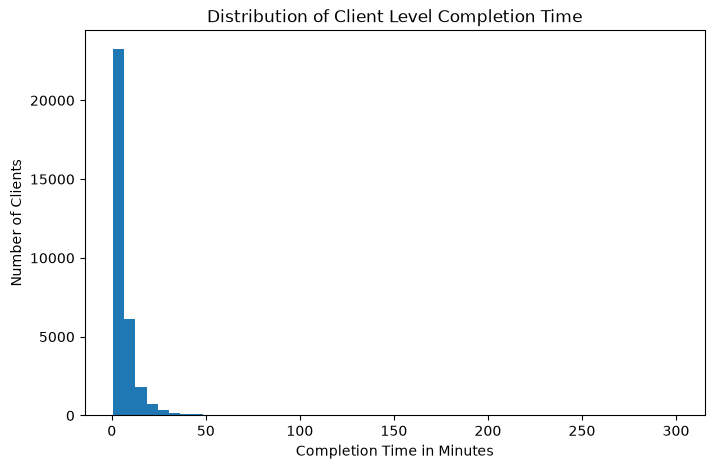

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    client_completion_time["completion_minutes"],
    bins=50
)

plt.xlabel("Completion Time in Minutes")
plt.ylabel("Number of Clients")
plt.title("Distribution of Client Level Completion Time")

plt.show()

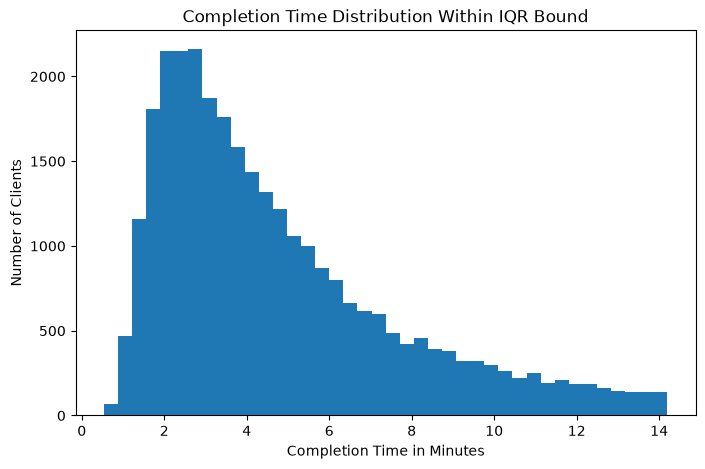

In [31]:
plt.figure(figsize=(8, 5))

plt.hist(
    client_completion_time[
        client_completion_time["completion_minutes"] <= upper_bound
    ]["completion_minutes"],
    bins=40
)

plt.xlabel("Completion Time in Minutes")
plt.ylabel("Number of Clients")
plt.title("Completion Time Distribution Within IQR Bound")

plt.show()

### Completion Time Validation

Completion time was calculated at the client level using each client's first valid successful journey. This ensures that each client contributes only one observation to the analysis.

A total of 32,791 clients had a measurable completion time, including 14,904 Control clients and 17,887 Test clients.

The completion time distribution is positively skewed. The overall median is substantially lower than the mean, and a small number of clients have very long completion times.

Using the IQR method, completion times above 14.22 minutes were identified as potential outliers. A total of 2,705 clients, representing 8.25% of the completion time population, were identified as outliers.

The outlier rates were similar between the groups, at 8.35% for Control and 8.17% for Test.

The outliers were retained because there is no evidence that they represent invalid observations. Long completion times may reflect genuine customer behaviour, such as pausing and returning to the process.

The Test group shows a lower mean and median completion time than the Control group. Statistical testing is required before concluding that this difference represents a significant treatment effect.

In [32]:
# Check skewness of client level completion time

overall_skewness = client_completion_time[
    "completion_minutes"
].skew()

group_skewness = (
    client_completion_time
    .groupby("Variation")["completion_minutes"]
    .skew()
)

print(
    "Overall skewness:",
    round(overall_skewness, 2)
)

print()

print("Skewness by variation:")
print(
    group_skewness.round(2)
)

Overall skewness: 7.9

Skewness by variation:
Variation
Control    8.69
Test       7.38
Name: completion_minutes, dtype: float64


### Distribution Assessment

The client level completion time distribution is strongly positively skewed.

Overall skewness was 7.90, with skewness of 8.69 for Control and 7.38 for Test. This confirms the right skew observed in the histograms and indicates that the completion time data are not approximately normally distributed.

Because of this distribution, the median provides an important descriptive measure alongside the mean.

The non normal distribution and presence of extreme values must also be considered when selecting the statistical test for the Control and Test comparison.

### Client Level Step Back Behavior

In [34]:
# Inspect backward navigation variable

print(
    web_clean_df["backward_navigation"]
    .value_counts(dropna=False)
)

print()

print(
    web_clean_df["backward_navigation"].dtype
)

backward_navigation
False    681761
True      62880
Name: count, dtype: int64

bool


In [35]:
# Calculate total step backs per client

client_step_backs = (
    experiment_web_df
    .groupby("client_id")["backward_navigation"]
    .sum()
    .reset_index(name="step_back_count")
)

client_step_backs.head()

,client_id,step_back_count
0,555,0
1,647,0
2,934,0
3,1028,2
4,1104,0


In [36]:
# Add step back count to client KPI dataset

client_kpi_df = client_kpi_df.merge(
    client_step_backs,
    on="client_id",
    how="left"
)

client_kpi_df["step_back_count"] = (
    client_kpi_df["step_back_count"]
    .fillna(0)
    .astype(int)
)

print(
    "Client KPI rows:",
    len(client_kpi_df)
)

print(
    "Unique clients:",
    client_kpi_df["client_id"].nunique()
)

print(
    "Missing step back counts:",
    client_kpi_df["step_back_count"].isna().sum()
)

print()

client_kpi_df[
    ["client_id", "Variation", "step_back_count"]
].head()

Client KPI rows: 50500
Unique clients: 50500
Missing step back counts: 0



,client_id,Variation,step_back_count
0,9988021,Test,2
1,8320017,Test,0
2,4033851,Control,3
3,1982004,Test,0
4,9294070,Control,0


In [37]:
# Step back distribution by variation

client_kpi_df.groupby(
    "Variation"
)["step_back_count"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Variation,,,,,,,,
Control,23532.0,0.41,0.86,0.0,0.0,0.0,1.0,16.0
Test,26968.0,0.60,1.21,0.0,0.0,0.0,1.0,25.0


In [38]:
# Percentage of clients with at least one step back

step_back_summary = (
    client_kpi_df
    .groupby("Variation")
    .agg(
        clients=("client_id", "count"),
        total_step_backs=("step_back_count", "sum"),
        clients_with_step_back=(
            "step_back_count",
            lambda x: (x > 0).sum()
        )
    )
)

step_back_summary["step_back_rate"] = (
    step_back_summary["clients_with_step_back"]
    / step_back_summary["clients"]
    * 100
)

step_back_summary.round(2)

,clients,total_step_backs,clients_with_step_back,step_back_rate
Variation,,,,
Control,23532,9581,6142,26.10
Test,26968,16232,9011,33.41


In [39]:
# Check client level step back distribution

print(
    client_kpi_df["step_back_count"]
    .value_counts()
    .sort_index()
)

print()

print(
    "Overall skewness:",
    round(
        client_kpi_df["step_back_count"].skew(),
        2
    )
)

print()

print("Skewness by variation:")

print(
    client_kpi_df
    .groupby("Variation")["step_back_count"]
    .skew()
    .round(2)
)

step_back_count
0     35347
1      9605
2      3025
3      1330
4       606
5       291
6       131
7        53
8        42
9        25
10       13
11        9
12        6
13        5
14        3
15        1
16        2
17        2
18        1
19        1
20        1
25        1
Name: count, dtype: int64

Overall skewness: 4.09

Skewness by variation:
Variation
Control    3.31
Test       4.10
Name: step_back_count, dtype: float64


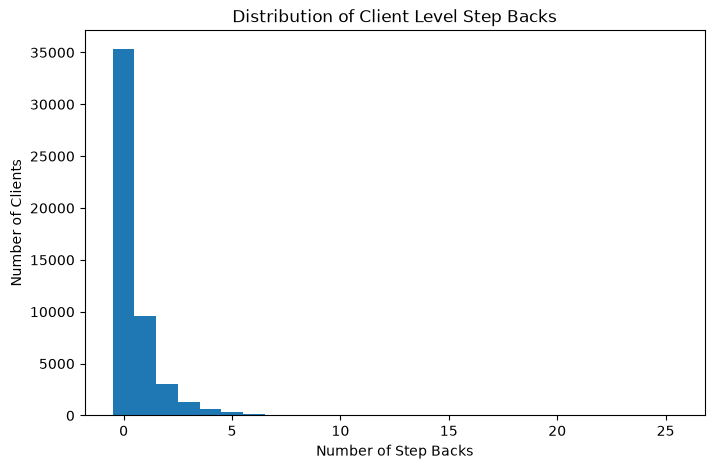

In [40]:
# Visualize client level step back distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    client_kpi_df["step_back_count"],
    bins=range(
        0,
        client_kpi_df["step_back_count"].max() + 2
    ),
    align="left"
)

plt.xlabel("Number of Step Backs")
plt.ylabel("Number of Clients")
plt.title("Distribution of Client Level Step Backs")

plt.show()

### Step Back KPI Validation

Step back behaviour was measured at the client level so that each randomized client contributes one independent observation.

The primary step back KPI measures whether a client experienced at least one backward navigation event. The secondary measure records the total number of backward navigation events per client.

In the Control group, 26.10% of clients experienced at least one step back, compared with 33.41% in the Test group. This represents an observed increase of 7.31 percentage points in the Test group.

The mean number of step backs was 0.41 for Control and 0.60 for Test.

The count distribution is strongly positively skewed. Overall skewness was 4.09, with values of 3.31 for Control and 4.10 for Test. Most clients recorded no step backs, while a small number experienced repeated backward navigation.

High step back counts were retained because they may represent genuine navigation difficulty rather than data errors.

Statistical testing is required before determining whether the observed difference between Control and Test represents a statistically significant treatment effect.

### Client level error

In [41]:
# Check process step values

web_clean_df["process_step"].value_counts(dropna=False)

process_step
start      234999
step_1     162797
step_2     132750
step_3     111589
confirm    102506
Name: count, dtype: int64

| KPI                | Analytical unit  |         Control |            Test | Role                       |
| ------------------ | ---------------- | --------------: | --------------: | -------------------------- |
| Completion Rate    | Client           |          65.59% |          69.29% | Primary outcome            |
| Noncompletion Rate | Client           |          34.41% |          30.71% | Complement of completion   |
| Completion Time    | Completed client | Median 4.52 min | Median 3.95 min | Efficiency                 |
| Step Back Rate     | Client           |          26.10% |          33.41% | Navigation friction        |
| Step Back Count    | Client           |       Mean 0.41 |       Mean 0.60 | Secondary friction measure |


### Error KPI Assessment

The web activity data was reviewed for an explicit error event or error status.

The recorded process steps consist only of `start`, `step_1`, `step_2`, `step_3`, and `confirm`. No explicit error event is available.

Therefore, an error rate KPI was not created. Inferring errors from repeated steps or backward navigation would require an additional methodological assumption and could duplicate the behaviour already measured by the step back KPI.

The analysis therefore retains step back behaviour as the primary measure of navigation friction.

### Final KPI Dataset Validation

In [42]:
# Final validation of client level KPI dataset

print("Total rows:", len(client_kpi_df))

print(
    "Unique clients:",
    client_kpi_df["client_id"].nunique()
)

print()

print("Clients by variation:")
print(
    client_kpi_df["Variation"].value_counts()
)

print()

print("Missing values:")
print(
    client_kpi_df[
        [
            "client_id",
            "Variation",
            "completed",
            "not_completed",
            "step_back_count"
        ]
    ].isna().sum()
)

Total rows: 50500
Unique clients: 50500

Clients by variation:
Variation
Test       26968
Control    23532
Name: count, dtype: int64

Missing values:
client_id          0
Variation          0
completed          0
not_completed      0
step_back_count    0
dtype: int64


In [43]:
# Validate completion time analytical population

print(
    "Completion time observations:",
    len(client_completion_time)
)

print(
    "Unique clients:",
    client_completion_time["client_id"].nunique()
)

print(
    "Missing completion times:",
    client_completion_time["completion_minutes"].isna().sum()
)

print()

print(
    client_completion_time["Variation"].value_counts()
)

Completion time observations: 32791
Unique clients: 32791
Missing completion times: 0

Variation
Test       17887
Control    14904
Name: count, dtype: int64


## Final KPI Methodology Summary

The primary analytical unit for the Vanguard A/B test is the client because experimental assignment occurred at the client level.

The final primary analytical population contains 50,500 unique clients, including 23,532 Control clients and 26,968 Test clients. Each client contributes one observation regardless of the number of journeys or attempts recorded.

### Completion Rate

A client is classified as completed if at least one `confirm` event is observed.

Control completion rate: 65.59%

Test completion rate: 69.29%

Observed difference: Test is 3.70 percentage points higher.

### Noncompletion Rate

Noncompletion is the complement of completion.

Control noncompletion rate: 34.41%

Test noncompletion rate: 30.71%

This metric is retained as a supporting business measure rather than a separate independent hypothesis.

### Completion Time

Completion time is calculated only for clients with a valid `start` followed by `confirm` within the same journey.

For clients with multiple successful journeys, the first successful completion is retained so that each client contributes only one completion time.

There are 32,791 clients with measurable completion time.

Control median: 4.52 minutes

Test median: 3.95 minutes

The distribution is strongly positively skewed and contains potential outliers. These observations are retained for the primary analysis and documented as part of the statistical assumptions.

### Step Back Behaviour

The primary navigation friction KPI measures whether a client experienced at least one backward navigation event.

Control step back rate: 26.10%

Test step back rate: 33.41%

The total number of step backs per client is retained as a secondary measure of navigation friction.

### Error Rate

No explicit error event exists in the Vanguard web activity data. Therefore, an error rate KPI was not created.

### Statistical Analysis

Statistical significance has not been determined in this notebook.

The validated client level KPI dataset will be used for the Control and Test hypothesis comparisons in the statistical analysis notebook.

In [44]:
# Save primary client level KPI dataset

client_kpi_df.to_csv(
    "data/cleaned/client_kpi_analysis.csv",
    index=False
)

print(
    "Saved:",
    "data/cleaned/client_kpi_analysis.csv"
)

Saved: data/cleaned/client_kpi_analysis.csv


In [45]:
# Save client level completion time dataset

client_completion_time[
    [
        "client_id",
        "Variation",
        "completion_minutes"
    ]
].to_csv(
    "data/cleaned/client_completion_time.csv",
    index=False
)

print(
    "Saved:",
    "data/cleaned/client_completion_time.csv"
)

Saved: data/cleaned/client_completion_time.csv


In [46]:
import os

print(
    os.path.exists(
        "data/cleaned/client_kpi_analysis.csv"
    )
)

print(
    os.path.exists(
        "data/cleaned/client_completion_time.csv"
    )
)

True
True


## Step backs by funnel stage

In [47]:
# Keep only backward navigation events

step_back_events = experiment_web_df[
    experiment_web_df["backward_navigation"] == True
].copy()

print("Total step back events:", len(step_back_events))

print()

step_back_events[
    [
        "client_id",
        "Variation",
        "previous_step",
        "process_step"
    ]
].head(10)

Total step back events: 25813



,client_id,Variation,previous_step,process_step
19,1028,Control,3.0,step_1
22,1028,Control,2.0,step_1
38,1197,Control,3.0,step_2
50,1346,Test,1.0,start
54,1346,Test,3.0,start
67,1516,Test,2.0,step_1
69,1516,Test,2.0,start
74,1516,Test,2.0,step_1
78,1643,Test,1.0,start
99,1836,Test,1.0,start


In [48]:
# Count backward transitions by variation

step_back_transitions = (
    step_back_events
    .groupby(
        [
            "Variation",
            "previous_step",
            "process_step"
        ]
    )
    .size()
    .reset_index(name="step_back_events")
)

step_back_transitions = step_back_transitions.sort_values(
    ["Variation", "step_back_events"],
    ascending=[True, False]
)

step_back_transitions

,Variation,previous_step,process_step,step_back_events
0,Control,1.0,start,2490
5,Control,3.0,step_2,2364
2,Control,2.0,step_1,1390
3,Control,3.0,start,1067
4,Control,3.0,step_1,815
1,Control,2.0,start,774
6,Control,4.0,start,482
8,Control,4.0,step_3,101
7,Control,4.0,step_1,98
9,Test,1.0,start,6404


In [49]:
# Percentage distribution of step backs within each variation

step_back_transitions["percentage"] = (
    step_back_transitions["step_back_events"]
    / step_back_transitions.groupby(
        "Variation"
    )["step_back_events"].transform("sum")
    * 100
)

step_back_transitions[
    [
        "Variation",
        "previous_step",
        "process_step",
        "step_back_events",
        "percentage"
    ]
].round(2)

,Variation,previous_step,process_step,step_back_events,percentage
0,Control,1.0,start,2490,25.99
5,Control,3.0,step_2,2364,24.67
2,Control,2.0,step_1,1390,14.51
3,Control,3.0,start,1067,11.14
4,Control,3.0,step_1,815,8.51
1,Control,2.0,start,774,8.08
6,Control,4.0,start,482,5.03
8,Control,4.0,step_3,101,1.05
7,Control,4.0,step_1,98,1.02
9,Test,1.0,start,6404,39.45


# Key finding:

The Test group's largest source of backward navigation is:

Step 1 → Start

It accounts for 39.45% of all Test step back events, compared with only 25.99% in Control.

There is also more Test backward navigation from:

Step 2 → Step 1

Test: 19.36%
Control: 14.51%

So the Test experience appears to generate more friction early in the process.

Interestingly, Control has substantially more:

Step 3 → Step 2

Control: 24.67%
Test: 14.06%

That means we should not simply say Test is worse at every stage. The location of friction changed.

# Of all step backs within each variation, where did they occur?
# How much more likely was a Test client to experience each type of step back?

In [50]:
# Client normalized step back transition rates

group_sizes = (
    valid_experiment_clients
    .groupby("Variation")["client_id"]
    .nunique()
)

step_back_transitions["clients_in_group"] = (
    step_back_transitions["Variation"]
    .map(group_sizes)
)

step_back_transitions["events_per_100_clients"] = (
    step_back_transitions["step_back_events"]
    / step_back_transitions["clients_in_group"]
    * 100
)

step_back_transitions[
    [
        "Variation",
        "previous_step",
        "process_step",
        "step_back_events",
        "events_per_100_clients"
    ]
].round(2)

,Variation,previous_step,process_step,step_back_events,events_per_100_clients
0,Control,1.0,start,2490,10.58
5,Control,3.0,step_2,2364,10.05
2,Control,2.0,step_1,1390,5.91
3,Control,3.0,start,1067,4.53
4,Control,3.0,step_1,815,3.46
1,Control,2.0,start,774,3.29
6,Control,4.0,start,482,2.05
8,Control,4.0,step_3,101,0.43
7,Control,4.0,step_1,98,0.42
9,Test,1.0,start,6404,23.75


| Backward transition | Control per 100 clients | Test per 100 clients | Difference |
| ------------------- | ----------------------: | -------------------: | ---------: |
| Step 1 → Start      |                   10.58 |            **23.75** | **+13.17** |
| Step 2 → Step 1     |                    5.91 |            **11.65** |  **+5.74** |
| Step 3 → Step 2     |               **10.05** |                 8.46 |      −1.59 |
| Step 3 → Start      |                    4.53 |             **8.29** |      +3.76 |
| Step 2 → Start      |                    3.29 |             **6.07** |      +2.78 |

### Funnel Location of Step Back Behaviour

Backward navigation was examined by funnel transition to identify where the increased navigation friction occurred.

The largest difference was observed between Step 1 and Start. The Control group generated 10.58 Step 1 to Start backward navigation events per 100 randomized clients, compared with 23.75 events per 100 clients in the Test group.

The Test group also generated more Step 2 to Step 1 backward navigation, with 11.65 events per 100 clients compared with 5.91 for Control.

The pattern was not consistent across every funnel stage. Step 3 to Step 2 backward navigation was lower in Test, at 8.46 events per 100 clients compared with 10.05 for Control.

These results indicate that the additional navigation friction observed in the Test experience is concentrated primarily in the earlier stages of the funnel.

The event data identifies where the friction occurs but does not establish why clients move backward. Further investigation of the Test interface around Start, Step 1, and Step 2 is therefore recommended.

# Day 5 implication

We now have a much stronger story:

Test performs better on the main outcome: completion increased from 65.59% to 69.29%.

Test completers are faster: median measurable completion time decreased from 4.52 to 3.95 minutes.

But Test creates more navigation friction: client step back rate increased from 26.10% to 33.41%.

And we now know where: the excess backward navigation is concentrated particularly around Step 1 → Start and Step 2 → Step 1.

That gives Day 5 an actionable direction: retain the elements of the Test experience associated with improved completion, while investigating and optimizing the early funnel rather than simply rejecting the redesigned experience.
